<a href="https://colab.research.google.com/github/AlexMoffatt10/COM7019/blob/main/Big_Data_and_Cloud_Computing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import sys

IN_COLAB = "google.colab" in sys.modules or os.path.exists("/content")

DATA_URL = (
    "https://raw.githubusercontent.com/archd3sai/"
    "Hourly-Energy-Consumption-Prediction/master/PJME_hourly.csv"
)

if IN_COLAB:
    DATA_PATH  = "/content/PJME_hourly.csv"
    OUTPUT_DIR = "/content/mes_poc_output"
else:
    DATA_PATH  = os.environ.get("DATA_PATH",  "data/PJME_hourly.csv")
    OUTPUT_DIR = os.environ.get("OUTPUT_DIR", "output")

os.makedirs(OUTPUT_DIR, exist_ok=True)

In [2]:
# 1. Import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error


if not IN_COLAB:
    import matplotlib
    matplotlib.use("Agg")

In [3]:
# 2. Dataset Download
if IN_COLAB and not os.path.exists(DATA_PATH):
    print("Downloading dataset...")
    import urllib.request
    urllib.request.urlretrieve(DATA_URL, DATA_PATH)
    print(f"Saved to {DATA_PATH}")

Saved to /content/PJME_hourly.csv


In [4]:
# 3. Pipeline functions
def ingest_and_clean(path: str) -> pd.DataFrame:
    """Ingestion and cleaning stage of the batch layer.

    Removes duplicate timestamps (DST clock-change artefacts — mirrors the
    veracity data quality issue MES faces with multi-vendor IoT feeds) and
    reindexes to a complete hourly range, interpolating small gaps.
    """
    df = pd.read_csv(path, parse_dates=["Datetime"])
    df = df.rename(columns={"Datetime": "timestamp", "PJME_MW": "demand_mw"})
    df = df.sort_values("timestamp")
    df = df.drop_duplicates(subset="timestamp", keep="first")
    df = df.set_index("timestamp")
    full_range = pd.date_range(df.index.min(), df.index.max(), freq="h")
    df = df.reindex(full_range)
    df["demand_mw"] = df["demand_mw"].interpolate(limit=6)
    df.index.name = "timestamp"
    return df.dropna()


def add_features(df: pd.DataFrame) -> pd.DataFrame:
    """Engineer calendar and lag features for the forecasting model."""
    df = df.copy()
    df["hour"]       = df.index.hour
    df["dayofweek"]  = df.index.dayofweek   # 0 = Monday
    df["month"]      = df.index.month
    df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)
    return df


def plot_daily_profile(df: pd.DataFrame, out_path: str):
    """Average demand by hour of day: identifies peak vs off-peak periods."""
    hourly_avg = df.groupby("hour")["demand_mw"].mean()
    peak_hour  = hourly_avg.idxmax()

    plt.figure(figsize=(8, 4.5))
    plt.plot(hourly_avg.index, hourly_avg.values, marker="o", color="#185fa5")
    plt.axvline(peak_hour, color="#993c1d", linestyle="--", alpha=0.6,
                label=f"Peak hour: {peak_hour}:00")
    plt.title("Average demand by hour of day (peak vs off-peak)")
    plt.xlabel("Hour of day")
    plt.ylabel("Average demand (MW)")
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_path, dpi=120)
    plt.show()
    plt.close()
    return peak_hour, hourly_avg.max()


def plot_seasonal_profile(df: pd.DataFrame, out_path: str):
    """Average demand by month: reveals seasonal demand pattern."""
    monthly_avg = df.groupby("month")["demand_mw"].mean()
    month_names = ["Jan","Feb","Mar","Apr","May","Jun",
                   "Jul","Aug","Sep","Oct","Nov","Dec"]

    plt.figure(figsize=(8, 4.5))
    plt.bar(monthly_avg.index, monthly_avg.values, color="#0f6e56")
    plt.xticks(monthly_avg.index, month_names)
    plt.title("Average demand by month (seasonal pattern)")
    plt.ylabel("Average demand (MW)")
    plt.tight_layout()
    plt.savefig(out_path, dpi=120)
    plt.show()
    plt.close()
    return monthly_avg


def forecast_peak_demand(df: pd.DataFrame, out_path: str):
    """Gradient-boosted demand forecast with a time-based 90-day holdout.

    A time-based split is used rather than a random split because randomly
    shuffling a time series would leak future values into training, producing
    unrealistically optimistic error metrics.
    """
    df = df.copy()
    df["lag_24h"]  = df["demand_mw"].shift(24)
    df["lag_168h"] = df["demand_mw"].shift(168)
    df = df.dropna()

    feature_cols = ["hour", "dayofweek", "month", "is_weekend",
                    "lag_24h", "lag_168h"]
    split_date = df.index.max() - pd.Timedelta(days=90)
    train = df[df.index <= split_date]
    test  = df[df.index >  split_date]

    model = GradientBoostingRegressor(
        n_estimators=150, max_depth=4, learning_rate=0.08, random_state=42
    )
    model.fit(train[feature_cols], train["demand_mw"])
    test_pred = model.predict(test[feature_cols])

    mae  = mean_absolute_error(test["demand_mw"], test_pred)
    mape = mean_absolute_percentage_error(test["demand_mw"], test_pred) * 100

    # Plot final 14 days of the test period: actual vs predicted
    window      = test.iloc[-336:]      # 14 days × 24 h
    window_pred = test_pred[-336:]

    plt.figure(figsize=(9, 4.5))
    plt.plot(window.index, window["demand_mw"],
             label="Actual demand", color="#185fa5")
    plt.plot(window.index, window_pred,
             label="Forecast", color="#993c1d", linestyle="--")
    plt.title(
        f"Demand forecast vs actual (final 14 days of test period)\n"
        f"MAE: {mae:.0f} MW  |  MAPE: {mape:.2f}%"
    )
    plt.xlabel("Date")
    plt.ylabel("Demand (MW)")
    plt.legend()
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.savefig(out_path, dpi=120)
    plt.show()
    plt.close()
    return mae, mape


[1/4] Ingesting and cleaning raw demand data...
      145,392 hourly records after cleaning (2002-01-01 to 2018-08-03)

[2/4] Profiling peak vs off-peak demand...


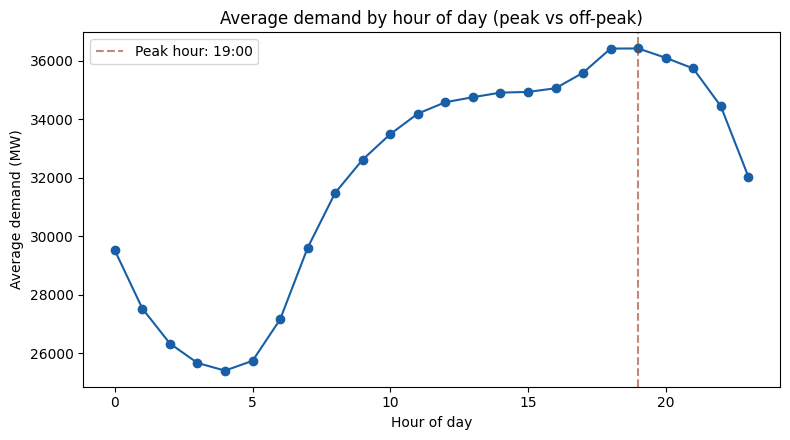

      Peak demand hour: 19:00  |  average 36,427 MW

[3/4] Profiling seasonal demand pattern...


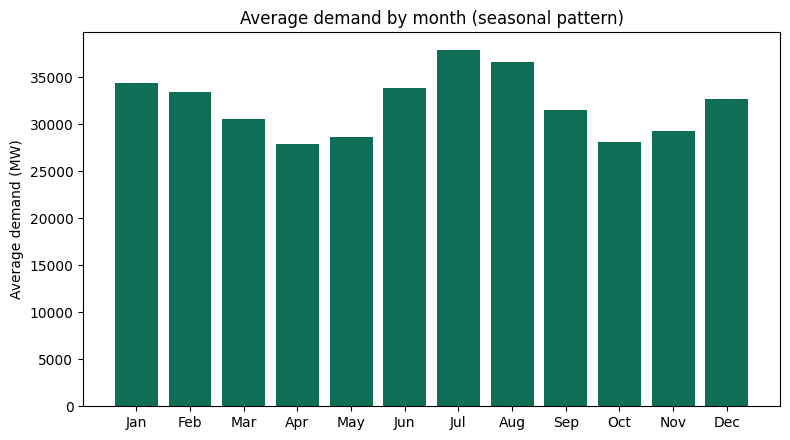

      Highest-demand month: 7  (37,882 MW avg)
      Lowest-demand month:  4  (27,861 MW avg)

[4/4] Training and evaluating demand forecast model...


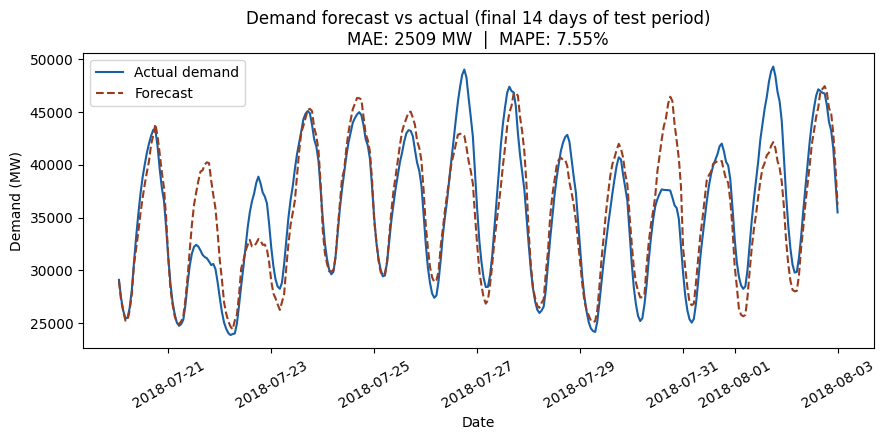

      Test MAE: 2509 MW  |  Test MAPE: 7.55%

Pipeline complete.


In [6]:
# 4. Main Pipeline
def main():
    print("[1/4] Ingesting and cleaning raw demand data...")
    df = ingest_and_clean(DATA_PATH)
    print(f"      {len(df):,} hourly records after cleaning "
          f"({df.index.min().date()} to {df.index.max().date()})")

    df = add_features(df)

    print("\n[2/4] Profiling peak vs off-peak demand...")
    peak_hour, peak_val = plot_daily_profile(
        df, f"{OUTPUT_DIR}/daily_profile.png"
    )
    print(f"      Peak demand hour: {peak_hour}:00  |  "
          f"average {peak_val:,.0f} MW")

    print("\n[3/4] Profiling seasonal demand pattern...")
    monthly_avg = plot_seasonal_profile(
        df, f"{OUTPUT_DIR}/seasonal_profile.png"
    )
    print(f"      Highest-demand month: {monthly_avg.idxmax()}  "
          f"({monthly_avg.max():,.0f} MW avg)")
    print(f"      Lowest-demand month:  {monthly_avg.idxmin()}  "
          f"({monthly_avg.min():,.0f} MW avg)")

    print("\n[4/4] Training and evaluating demand forecast model...")
    mae, mape = forecast_peak_demand(
        df, f"{OUTPUT_DIR}/forecast_vs_actual.png"
    )
    print(f"      Test MAE: {mae:.0f} MW  |  Test MAPE: {mape:.2f}%")

    print(f"\nPipeline complete.")


if __name__ == "__main__":
    main()